# DOE vs. Random Initialization — Active Learning Experiment

**Project:** Molecular Active Learning for HIV Drug Discovery  
**Goal:** Compare three initialization strategies for the active learning starting set:
- **Random** — uniform random selection (baseline)
- **MaxMin** — greedy Tanimoto diversity (DOE analog)
- **k-Medoids** — cluster-based selection (LHS analog)

All three use the same base learner (Random Forest), same batch size (500),  
same acquisition function (uncertainty sampling via RF entropy), and same  
scaffold-split test set — so any difference in AUPRC curves is attributable  
**purely to the initialization strategy**.

---
**Run order:** Execute cells top to bottom. Each cell is labeled with what it does.

## Cell 1 — Install Dependencies

Safe to re-run: already-installed packages are skipped by pip.

In [1]:
import subprocess, sys

def pip(cmd):
    subprocess.check_call([sys.executable, "-m", "pip", "install"] + cmd.split() + ["-q"])

# Step 1: pin numpy to a version compatible with Colab's pre-built packages
pip("numpy==1.26.4")

# Step 2: install everything else AFTER numpy is pinned
pip("PyTDC")
pip("kmedoids")

In [4]:
print("\nVerifying imports...")
import numpy;   print(f"numpy      {numpy.__version__}")
import rdkit;   print(f"rdkit      {rdkit.__version__}")
import sklearn; print(f"sklearn    {sklearn.__version__}")

# TDC — test the actual import used in data_loader.py
from tdc.single_pred import HTS
print("pytdc      OK")

# kmedoids — test the actual function used in kmedoids_init.py
from kmedoids import fasterpam
print("kmedoids   OK")

print("\nAll good — proceed to Cell 2.")


Verifying imports...
numpy      1.26.4
rdkit      2023.09.6
sklearn    1.2.2
pytdc      OK
kmedoids   OK

All good — proceed to Cell 2.


In [5]:
# Cell 2 — Mount Drive and set project root
from google.colab import drive
drive.mount('/content/drive')

import os, sys
PROJECT_ROOT = '/content/drive/MyDrive/ASR_Project'  # ← your Drive path
sys.path.insert(0, PROJECT_ROOT)
print(f"Project root: {PROJECT_ROOT}")

Mounted at /content/drive
Project root: /content/drive/MyDrive/ASR_Project


## Cell 2 — Set Project Root on sys.path

This tells Python where to find `preprocessing/`, `initialization/`, etc.  
**Change `PROJECT_ROOT` to match your actual folder path.**

In [7]:
import os, sys

# ── SET THIS TO YOUR ASR_PROJECT ROOT ─────────────────────────────────────
# This is the folder that CONTAINS preprocessing/, initialization/, models/, etc.
# Examples:
#   Local Mac/Linux : '/Users/skothare/python/ASR_Project'
#   Google Drive    : '/content/drive/MyDrive/ASR_Project'
#   Windows         : 'C:/Users/skothare/ASR_Project'

PROJECT_ROOT = '/content/drive/MyDrive/ASR_Project'  # <-- CHANGE THIS ACCORDINGLY

# ──────────────────────────────────────────────────────────────────────────

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# Verify the key folders exist
for folder in ['preprocessing/data', 'initialization', 'models',
               'active_learning', 'evaluation', 'experiments']:
    full = os.path.join(PROJECT_ROOT, folder)
    status = '✓' if os.path.isdir(full) else '✗ MISSING'
    print(f"  {status}  {folder}/")

# Check data file
hiv_path = os.path.join(PROJECT_ROOT, 'preprocessing', 'data', 'hiv.tab')
print(f"  {'✓' if os.path.exists(hiv_path) else '✗ MISSING'}  preprocessing/data/hiv.tab")

print(f"\nProject root: {PROJECT_ROOT}")

  ✓  preprocessing/data/
  ✓  initialization/
  ✓  models/
  ✓  active_learning/
  ✓  evaluation/
  ✓  experiments/
  ✓  preprocessing/data/hiv.tab

Project root: /content/drive/MyDrive/ASR_Project


## Cell 3 — Check __init__.py Files Exist

Python needs `__init__.py` in every folder it imports from as a package.  
This cell creates any that are missing.

In [8]:
packages = [
    'preprocessing',
    'preprocessing/data',
    'initialization',
    'models',
    'active_learning',
    'evaluation',
    'experiments',
]

for pkg in packages:
    init_path = os.path.join(PROJECT_ROOT, pkg, '__init__.py')
    if not os.path.exists(init_path):
        open(init_path, 'w').close()
        print(f"  Created: {pkg}/__init__.py")
    else:
        print(f"  OK:      {pkg}/__init__.py")

# Also create results/ directory if it doesn't exist
results_dir = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(results_dir, exist_ok=True)
print(f"  OK:      results/")

  Created: preprocessing/__init__.py
  OK:      preprocessing/data/__init__.py
  OK:      initialization/__init__.py
  OK:      models/__init__.py
  OK:      active_learning/__init__.py
  OK:      evaluation/__init__.py
  OK:      experiments/__init__.py
  OK:      results/


## Cell 4 — Load and Preview the HIV Dataset

This is a good sanity check before running the full experiment.  
Verifies fingerprints compute correctly and shows class distribution.

In [13]:
import importlib
import preprocessing.data.data_loader as _m
importlib.reload(_m)
from preprocessing.data.data_loader import load_hiv_data

data = load_hiv_data()

print("\nDataBundle summary:")
print(f"  Train pool : {data.X_train_pool.shape}  "
      f"({data.y_train_pool.sum()} actives = "
      f"{100*data.y_train_pool.mean():.1f}%)")
print(f"  Validation : {data.X_val.shape}  "
      f"({data.y_val.sum()} actives)")
print(f"  Test       : {data.X_test.shape}  "
      f"({data.y_test.sum()} actives)")
print(f"  Fingerprint shape: {data.X_train_pool.shape[1]}-bit Morgan")

Found local copy...
Loading...


Loading HIV dataset from TDC ...


Done!
100%|██████████| 41127/41127 [00:19<00:00, 2147.55it/s]


Computing 2048-bit Morgan fingerprints (radius=2) ...
  Train pool : 28,788 molecules
  Validation : 4,112 molecules
  Test       : 8,227 molecules
  Active fraction in train pool: 0.037  (1055 actives / 28788 total)

DataBundle summary:
  Train pool : (28788, 2048)  (1055 actives = 3.7%)
  Validation : (4112, 2048)  (107 actives)
  Test       : (8227, 2048)  (281 actives)
  Fingerprint shape: 2048-bit Morgan


## Cell 5 — Quick Initialization Preview (Optional)

Run this to verify each initialization strategy works before committing  
to the full experiment. Uses a tiny n_init=50 so it's fast.

In [14]:
import numpy as np
from initialization.random_init   import random_initialization
from initialization.maxmin_init   import maxmin_initialization
from initialization.kmedoids_init import kmedoids_initialization

N = len(data.y_train_pool)
TEST_N_INIT = 50   # small for quick preview

print("Testing Random init...")
idx_random = random_initialization(n_total=N, n_init=TEST_N_INIT, seed=0)
print(f"  Selected {len(idx_random)} indices, "
      f"actives: {data.y_train_pool[idx_random].sum()}")

print("\nTesting MaxMin init (small n_init so this is fast)...")
idx_maxmin = maxmin_initialization(
    X_pool=data.X_train_pool, n_init=TEST_N_INIT, seed=0, verbose=True
)
print(f"  Selected {len(idx_maxmin)} indices, "
      f"actives: {data.y_train_pool[idx_maxmin].sum()}")

print("\nTesting k-Medoids init...")
idx_kmed = kmedoids_initialization(
    X_pool=data.X_train_pool, n_init=TEST_N_INIT,
    seed=0, subsample_size=500, verbose=True
)
print(f"  Selected {len(idx_kmed)} indices, "
      f"actives: {data.y_train_pool[idx_kmed].sum()}")

print("\nAll three initialization strategies working correctly.")

Testing Random init...
  Selected 50 indices, actives: 1

Testing MaxMin init (small n_init so this is fast)...
MaxMin init: selecting 50 molecules from pool of 28,788
  Step 49/50  |  max min-dist = 0.9189
  Selected 50 indices, actives: 1

Testing k-Medoids init...
k-Medoids init: 50 clusters, subsample=500 / 28,788
  Computing Tanimoto distance matrix on subsample ...
  Running PAM k-Medoids (k=50) ...
  Done.  50 medoids selected.
  Selected 50 indices, actives: 2

All three initialization strategies working correctly.


## Cell 6 — Configure the Experiment

Adjust these parameters before running the full experiment.  
Defaults match your teammate's established settings.

In [ ]:
# Experiment configuration 

INIT_FRACTION = 0.20   # 20% starting pool (from your teammate's starting-fraction experiment)
BATCH_SIZE    = 500    # molecules added per AL iteration (from batch-size grid search)
N_SEEDS       = 3      # seeds to average over (set to 1 for a quick first pass)
RF_ESTIMATORS = 100    # number of trees in Random Forest

# Override the config in run_doe_comparison.py
import experiments.run_doe_comparison as exp
exp.INIT_FRACTION = INIT_FRACTION
exp.BATCH_SIZE    = BATCH_SIZE
exp.N_SEEDS       = N_SEEDS
exp.RF_ESTIMATORS = RF_ESTIMATORS
exp.RESULTS_DIR   = os.path.join(PROJECT_ROOT, 'results')

n_init = int(len(data.y_train_pool) * INIT_FRACTION)
print(f"Experiment configuration:")
print(f"  Init fraction : {INIT_FRACTION*100:.0f}%  ({n_init:,} molecules)")
print(f"  Batch size    : {BATCH_SIZE}")
print(f"  Seeds         : {N_SEEDS}")
print(f"  RF trees      : {RF_ESTIMATORS}")
print(f"  Results dir   : {exp.RESULTS_DIR}")
print(f"\nEstimated runtime (CPU):")
print(f"  MaxMin init   : ~5-15 min per seed")
print(f"  AL loop       : ~20-30 min per (condition × seed)")
print(f"  Total         : ~3-4 hrs for {N_SEEDS} seeds × 3 conditions")
print(f"  Quick test    : set N_SEEDS=1 for ~1 hr total")

Experiment configuration:
  Init fraction : 20%  (5,757 molecules)
  Batch size    : 500
  Seeds         : 3
  RF trees      : 100
  Results dir   : /content/drive/MyDrive/ASR_Project/results

Estimated runtime (CPU):
  MaxMin init   : ~5-15 min per seed
  AL loop       : ~20-30 min per (condition × seed)
  Total         : ~3-4 hrs for 3 seeds × 3 conditions
  Quick test    : set N_SEEDS=1 for ~1 hr total


## Cell 7 — Run the Full Experiment

This runs all 3 conditions × N_SEEDS seeds.  
Results are checkpointed to `results/` after each (condition, seed) pair —  
so if the kernel crashes, you won't lose completed runs.

**Progress is printed live.** Watch for the AUPRC values increasing.

In [16]:
from experiments.run_doe_comparison import main

main()

Found local copy...
Loading...
Done!


Loading HIV dataset from TDC ...


100%|██████████| 41127/41127 [00:19<00:00, 2110.92it/s]


Computing 2048-bit Morgan fingerprints (radius=2) ...
  Train pool : 28,788 molecules
  Validation : 4,112 molecules
  Test       : 8,227 molecules
  Active fraction in train pool: 0.037  (1055 actives / 28788 total)

  Condition : Random
  Seed      : 0
  n_init    : 5,757 / 28,788 (20%)
  Initialisation done in 0.0s

AL loop starting
  Init set : 5,757 molecules  (206 actives = 3.6%)
  Pool size: 28,788   Batch size: 500
  Max iterations: 47
  Iter   0 | labeled= 5,757 | AUPRC=0.2838 | AUROC=0.7695 | hits=0.195
  Iter   1 | labeled= 6,257 | AUPRC=0.3388 | AUROC=0.7395 | hits=0.438
  Iter   2 | labeled= 6,757 | AUPRC=0.3521 | AUROC=0.7586 | hits=0.543
  Iter   5 | labeled= 8,257 | AUPRC=0.3899 | AUROC=0.7615 | hits=0.685
  Iter  10 | labeled=10,757 | AUPRC=0.3786 | AUROC=0.7708 | hits=0.760
  Iter  15 | labeled=13,257 | AUPRC=0.3722 | AUROC=0.7563 | hits=0.804
  Iter  20 | labeled=15,757 | AUPRC=0.3706 | AUROC=0.7657 | hits=0.857
  Iter  25 | labeled=18,257 | AUPRC=0.3843 | AUROC=0.77

ValueError: Cannot take a larger sample than population when 'replace=False'

In [19]:
from experiments.run_doe_comparison import run_one_condition, results_to_dict
import json, os

n_init = int(len(data.y_train_pool) * 0.20)

for seed in range(3):
    result = run_one_condition(
        condition_name='kMedoids',
        init_fn=lambda seed=seed: kmedoids_initialization(
            X_pool=data.X_train_pool,
            n_init=n_init,
            seed=seed,
            subsample_size=n_init + 500,  # fixed
            verbose=True,
        ),
        data=data,
        seed=seed,
    )
    path = os.path.join(PROJECT_ROOT, 'results', f'doe_comparison_kmedoids_seed{seed}.json')
    with open(path, 'w') as f:
        json.dump(result, f, indent=2)
    print(f"Saved seed {seed}")


  Condition : kMedoids
  Seed      : 0
  n_init    : 5,757 / 28,788 (20%)
k-Medoids init: 5,757 clusters, subsample=6,257 / 28,788
  Computing Tanimoto distance matrix on subsample ...
  Running PAM k-Medoids (k=5757) ...
  Done.  5757 medoids selected.
  Initialisation done in 89.0s

AL loop starting
  Init set : 5,757 molecules  (187 actives = 3.2%)
  Pool size: 28,788   Batch size: 500
  Max iterations: 47
  Iter   0 | labeled= 5,757 | AUPRC=0.2832 | AUROC=0.7614 | hits=0.177
  Iter   1 | labeled= 6,257 | AUPRC=0.3234 | AUROC=0.7402 | hits=0.412
  Iter   2 | labeled= 6,757 | AUPRC=0.3558 | AUROC=0.7533 | hits=0.520
  Iter   5 | labeled= 8,257 | AUPRC=0.3722 | AUROC=0.7629 | hits=0.676
  Iter  10 | labeled=10,757 | AUPRC=0.3737 | AUROC=0.7506 | hits=0.755
  Iter  15 | labeled=13,257 | AUPRC=0.3833 | AUROC=0.7567 | hits=0.806
  Iter  20 | labeled=15,757 | AUPRC=0.3819 | AUROC=0.7729 | hits=0.856
  Iter  25 | labeled=18,257 | AUPRC=0.3795 | AUROC=0.7845 | hits=0.888
  Iter  30 | label

## Cell 8 — Load and Re-Plot Results (run any time after Cell 7)

If Cell 7 already ran (even in a previous session), you can re-plot  
without re-running the experiment — just load the saved JSON.

In [17]:
import json
import matplotlib.pyplot as plt
import numpy as np

summary_path = os.path.join(PROJECT_ROOT, 'results', 'doe_comparison_summary.json')

if not os.path.exists(summary_path):
    print(f"Summary not found at {summary_path}")
    print("Run Cell 7 first to generate results.")
else:
    with open(summary_path) as f:
        summary = json.load(f)

    from experiments.run_doe_comparison import plot_doe_comparison
    plot_path = os.path.join(PROJECT_ROOT, 'results', 'doe_comparison_plot.png')
    plot_doe_comparison(summary, save_path=plot_path)
    print(f"Plot saved to {plot_path}")

Summary not found at /content/drive/MyDrive/ASR_Project/results/doe_comparison_summary.json
Run Cell 7 first to generate results.


## Cell 9 — Inspect Individual Seed Results (debugging / deep dive)

Load a specific (condition, seed) checkpoint to inspect the raw numbers.

In [ ]:
import json, os

CONDITION = 'random'   # options: 'random', 'maxmin', 'kmedoids'
SEED      = 0

ckpt_path = os.path.join(
    PROJECT_ROOT, 'results',
    f'doe_comparison_{CONDITION}_seed{SEED}.json'
)

if not os.path.exists(ckpt_path):
    print(f"Checkpoint not found: {ckpt_path}")
else:
    with open(ckpt_path) as f:
        r = json.load(f)

    import matplotlib.pyplot as plt
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(r['n_labeled'], r['auprc'])
    ax1.set_xlabel('Labeled molecules')
    ax1.set_ylabel('AUPRC')
    ax1.set_title(f'{CONDITION.capitalize()} seed={SEED} — AUPRC')
    ax1.grid(True, alpha=0.3)

    ax2.plot(r['n_labeled'], r['auroc'])
    ax2.set_xlabel('Labeled molecules')
    ax2.set_ylabel('AUROC')
    ax2.set_title(f'{CONDITION.capitalize()} seed={SEED} — AUROC')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Final AUPRC: {r['auprc'][-1]:.4f}")
    print(f"Final AUROC: {r['auroc'][-1]:.4f}")
    print(f"Iterations : {len(r['n_labeled'])}")

Loaded random: 3 seed(s)
Loaded maxmin: 3 seed(s)
Loaded kmedoids: 3 seed(s)


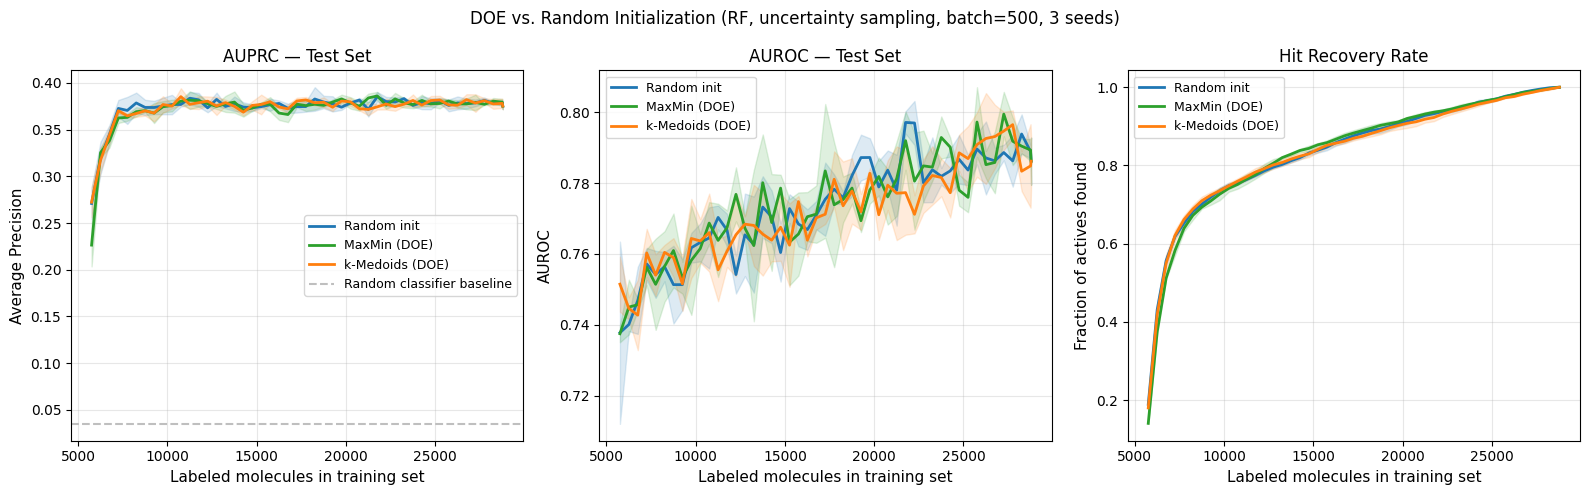

Saved to /content/drive/MyDrive/ASR_Project/results/partial_results_plot.png


In [ ]:
import json, os, numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = '/content/drive/MyDrive/ASR_Project'
RESULTS_DIR  = os.path.join(PROJECT_ROOT, 'results')

def load_checkpoint(condition, seed):
    path = os.path.join(RESULTS_DIR, f'doe_comparison_{condition}_seed{seed}.json')
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return None

def aggregate(seed_results):
    ref_x = seed_results[0]['n_labeled']
    auprc_mat = np.stack([np.interp(ref_x, r['n_labeled'], r['auprc']) for r in seed_results])
    auroc_mat = np.stack([np.interp(ref_x, r['n_labeled'], r['auroc']) for r in seed_results])
    hits_mat  = np.stack([np.interp(ref_x, r['n_labeled'], r['hit_recovery']) for r in seed_results])
    return {
        'n_labeled':  ref_x,
        'auprc_mean': auprc_mat.mean(0), 'auprc_std': auprc_mat.std(0),
        'auroc_mean': auroc_mat.mean(0), 'auroc_std': auroc_mat.std(0),
        'hits_mean':  hits_mat.mean(0),  'hits_std':  hits_mat.std(0),
    }

# ── load whatever checkpoints exist 
conditions_available = {}
for cond in ['random', 'maxmin', 'kmedoids']:
    seeds = [load_checkpoint(cond, s) for s in range(3)]
    seeds = [s for s in seeds if s is not None]
    if seeds:
        conditions_available[cond] = aggregate(seeds)
        print(f"Loaded {cond}: {len(seeds)} seed(s)")
    else:
        print(f"Skipping {cond}: no checkpoints found")

#plot
colours = {'random': '#1f77b4', 'maxmin': '#2ca02c', 'kmedoids': '#ff7f0e'}
labels  = {'random': 'Random init', 'maxmin': 'MaxMin (DOE)', 'kmedoids': 'k-Medoids (DOE)'}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for metric, ax, title, ylabel in [
    ('auprc', axes[0], 'AUPRC — Test Set', 'Average Precision'),
    ('auroc', axes[1], 'AUROC — Test Set', 'AUROC'),
    ('hits',  axes[2], 'Hit Recovery Rate', 'Fraction of actives found'),
]:
    for cond, agg in conditions_available.items():
        x    = np.array(agg['n_labeled'])
        mean = agg[f'{metric}_mean']
        std  = agg[f'{metric}_std']
        ax.plot(x, mean, label=labels[cond], color=colours[cond], linewidth=2)
        ax.fill_between(x, mean - std, mean + std, color=colours[cond], alpha=0.15)

    if metric == 'auprc':
        ax.axhline(0.035, linestyle='--', color='grey', alpha=0.5, label='Random classifier baseline')

    ax.set_xlabel('Labeled molecules in training set', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle('DOE vs. Random Initialization (RF, uncertainty sampling, batch=500, 3 seeds)',
             fontsize=12)
plt.tight_layout()
plot_path = os.path.join(RESULTS_DIR, 'partial_results_plot.png')
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {plot_path}")